# State-Level SNAP Benefits, Socioeconomic Factors, and Cost of Living

## Motivation

The Supplemental Nutrition Assistance Program (SNAP) is one of the largest food assistance programs in the United States. It is designed to reduce food insecurity by providing benefits that help low-income households purchase groceries. Although SNAP is a federal program, **benefit levels and implementation details can vary across states**, leading to meaningful differences in support received by otherwise similar households depending on where they live.

At the same time, states differ widely in **median income, cost of living, and demographic composition**. A state with higher housing and food prices may need to provide more generous benefits to maintain the same purchasing power. Likewise, differences in income and racial composition may correlate with different policy choices or levels of need.

This project focuses on **state-level variation in SNAP benefits per participant**. By combining SNAP program data with socioeconomic and demographic indicators, we aim to better understand:

- How strongly benefits per person are associated with income and cost of living.
- Whether demographic factors appear to be correlated with benefit levels.
- Whether states that “look similar” on these characteristics end up with similar SNAP benefits.

## Research Questions

1. **How do income levels, cost of living, and demographic composition relate to SNAP benefits per person across U.S. states?**

2. **Can we build predictive models that estimate SNAP benefits per participant from socioeconomic and demographic variables, and how accurate are these models?**

3. **Do states cluster into meaningful groups based on income, cost of living, racial composition, and SNAP benefit levels, and what distinguishes these groups?**


## Data Sources and Provenance

This project integrates several publicly available, reputable datasets to construct a state-level view of SNAP benefits, income, cost of living, and demographic composition. All data are aggregated to the state level and aligned by state name or FIPS-like identifiers.

### 1. SNAP Benefits and Participation (USDA)

- **Source:** U.S. Department of Agriculture (USDA), Supplemental Nutrition Assistance Program.
- **Files used:** `snap-benefits-8.csv`, `snap-persons-8.csv`.
- **Content:** Monthly total SNAP benefits (dollars) and total number of participants (persons) for each U.S. state and territory.
- **Use in analysis:**  
  - We focus on the most recent month available in our extract.
  - We compute **benefits per person** as  

    \[
    \text{benefits\_per\_person} = \frac{\text{total\_benefits}}{\text{total\_persons}}
    \]

    to standardize benefit levels across states.

- **Notes:**  
  Territories (e.g., Guam, Virgin Islands) are removed to keep the analysis focused on the 50 states and the District of Columbia.

### 2. Median Household Income (ACS)

- **Source:** U.S. Census Bureau, American Community Survey (ACS) 1-year estimates.
- **File used:** `ACSDT1Y2024.B19013-Data.csv`.
- **Content:** State-level estimates of **median household income** (in dollars).
- **Use in analysis:**  
  - Merged to states to provide an economic indicator of typical household resources.
  - Used as a predictor in regression models and as an input to clustering.

### 3. Racial Composition (ACS)

- **Source:** U.S. Census Bureau, American Community Survey (ACS) 1-year estimates.
- **File used:** `ACSDT1Y2024.B02001-Data.csv`.
- **Content:** Counts by race (e.g., White alone, Black or African American alone, American Indian/Alaska Native, Asian, Native Hawaiian/Pacific Islander, two or more races).
- **Use in analysis:**  
  - Converted to **percentages of the state population** (e.g., `white_pct`, `black_pct`, etc.).
  - Used as demographic predictors and as features in clustering.

### 4. Cost of Living Index (COLI)

- **Source:** Publicly available cost of living index dataset (e.g., based on Council for Community and Economic Research or similar compiled data).
- **File used:** `cost_of_living_index.csv`.
- **Content:** State-level cost of living index values, typically normalized so that 100 represents the U.S. average.
- **Use in analysis:**  
  - Merged to states to approximate the **relative cost of goods and services**.
  - Used in correlation analysis, regression, and clustering.

### 5. Final Analytical Dataset

After cleaning, merging, and filtering to the 50 states + DC, we obtain a final dataset that includes:

- `benefits_per_person` (USDA SNAP)
- `median_income` (ACS)
- `coli` (cost of living index)
- Racial composition percentages (`white_pct`, `black_pct`, `native_pct`, `asian_pct`, `pacific_pct`, `two_plus_pct`)
- Region indicators (e.g., Northeast, Midwest, South, West) derived from state names

This merged dataset is the basis for all descriptive statistics, visualizations, predictive models, and clustering analyses in the project.


In [14]:
# =============================
# Section 3: Imports & Settings
# =============================

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Display options
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

sns.set(style="whitegrid")

print("Libraries loaded and display settings configured.")


Libraries loaded and display settings configured.


In [15]:
# =============================
# Section 4: Load USDA SNAP Data
# =============================

# Load benefits and persons files (adjust filenames if needed)
benefits = pd.read_csv("snap-benefits-8.csv", skiprows=2)
persons = pd.read_csv("snap-persons-8.csv", skiprows=2)

# Clean column names
benefits.columns = (
    benefits.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

persons.columns = (
    persons.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

print("Benefits columns:", benefits.columns.tolist())
print("Persons columns:", persons.columns.tolist())

benefits.head()


Benefits columns: ['state_/_territory', 'may_2024', 'april_2025_preliminary', 'may_2025_initial', 'percent_change_may_2025_vs_april_2025', 'percent_change_may_2025_vs_may_2024']
Persons columns: ['state_/_territory', 'may_2024', 'april_2025_preliminary', 'may_2025_initial', 'percent_change_may_2025_vs_april_2025', 'percent_change_may_2025_vs_may_2024']


,state_/_territory,may_2024,april_2025_preliminary,may_2025_initial,percent_change_may_2025_vs_april_2025,percent_change_may_2025_vs_may_2024
0,Alabama,"127,527,483","141,885,914","142,142,795",0.2%,11.5%
1,Alaska,"22,704,902","21,854,992","24,181,479",10.6%,6.5%
2,American Samoa,NaN,NaN,NaN,--,--
3,Arizona,"161,957,481","161,431,076","161,705,602",0.2%,-0.2%
4,Arkansas,"37,779,257","41,862,894","41,434,391",-1.0%,9.7%


## Data Cleaning and Feature Engineering

Before modeling, we perform several cleaning and transformation steps:

1. **Select latest SNAP month and compute benefits per person**
   - Keep the most recent month of total benefits and total participants for each state.
   - Standardize state names and merge benefits with persons.
   - Compute `benefits_per_person = total_benefits / total_persons`.

2. **Filter geography**
   - Drop territories and keep only the 50 states and the District of Columbia to maintain comparability.

3. **Clean ACS income and race tables**
   - Standardize column names (lowercase, snake_case).
   - Keep the relevant median income and race columns.
   - Convert race counts to **shares of the total state population** (e.g., `white_pct`, `black_pct`).

4. **Clean and merge the cost of living index (COLI)**
   - Standardize state names.
   - Keep a single COLI value per state (most recent year).
   - Merge into the SNAP + ACS dataset.

5. **Handle missing values and final selection**
   - Drop rows where key variables (`benefits_per_person`, `median_income`, `coli`) are missing.
   - Confirm that the final dataset contains one row per state and all predictors needed for modeling.

These steps produce the `snap_full` dataset used for all subsequent exploration, modeling, and clustering.


In [17]:
# ======================================================
# Section 5: Clean SNAP Data & Compute Benefits/Person
# ======================================================

# 1. Select the latest month (May 2025 initial)
benefits_latest = benefits[['state_/_territory', 'may_2025_initial']].rename(
    columns={'state_/_territory': 'state', 'may_2025_initial': 'total_benefits'}
)

persons_latest = persons[['state_/_territory', 'may_2025_initial']].rename(
    columns={'state_/_territory': 'state', 'may_2025_initial': 'total_persons'}
)

# 2. Clean state names
benefits_latest['state'] = benefits_latest['state'].str.strip().str.title()
persons_latest['state'] = persons_latest['state'].str.strip().str.title()

# 3. Replace '--' and commas, convert to float
benefits_latest['total_benefits'] = (
    benefits_latest['total_benefits']
    .astype(str)
    .str.replace(',', '')
    .replace('--', np.nan)
)

persons_latest['total_persons'] = (
    persons_latest['total_persons']
    .astype(str)
    .str.replace(',', '')
    .replace('--', np.nan)
)

# Convert to numeric (coerce remaining bad values to NaN)
benefits_latest['total_benefits'] = pd.to_numeric(benefits_latest['total_benefits'], errors='coerce')
persons_latest['total_persons'] = pd.to_numeric(persons_latest['total_persons'], errors='coerce')

# 4. Merge benefits + persons
snap = benefits_latest.merge(persons_latest, on='state', how='inner')

# 5. Drop rows with missing or zero values
snap = snap.dropna(subset=['total_benefits', 'total_persons'])
snap = snap[snap['total_persons'] > 0]

# 6. Compute benefits per person
snap['benefits_per_person'] = snap['total_benefits'] / snap['total_persons']

# 7. Restrict to 50 states + DC
states_50_dc = {
    'Alabama','Alaska','Arizona','Arkansas','California','Colorado','Connecticut','Delaware',
    'District Of Columbia','Florida','Georgia','Hawaii','Idaho','Illinois','Indiana','Iowa',
    'Kansas','Kentucky','Louisiana','Maine','Maryland','Massachusetts','Michigan','Minnesota',
    'Mississippi','Missouri','Montana','Nebraska','Nevada','New Hampshire','New Jersey',
    'New Mexico','New York','North Carolina','North Dakota','Ohio','Oklahoma','Oregon',
    'Pennsylvania','Rhode Island','South Carolina','South Dakota','Tennessee','Texas','Utah',
    'Vermont','Virginia','Washington','West Virginia','Wisconsin','Wyoming'
}

snap_usa = snap[snap['state'].isin(states_50_dc)].copy()

print("Shape of SNAP-USA (50 states + DC):", snap_usa.shape)
snap_usa.head()


Shape of SNAP-USA (50 states + DC): (51, 4)


,state,total_benefits,total_persons,benefits_per_person
0,Alabama,"142,142,795.000","736,178.000",193.082
1,Alaska,"24,181,479.000","66,377.000",364.305
3,Arizona,"161,705,602.000","887,253.000",182.254
4,Arkansas,"41,434,391.000","239,748.000",172.825
5,California,"1,045,310,679.000","5,494,318.000",190.253


In [18]:
# ============================================
# Section 6: Load ACS Median Income (B19013)
# ============================================

income_raw = pd.read_csv("ACSDT1Y2024.B19013-Data.csv", dtype=str)

# Clean column names
income_raw.columns = (
    income_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

# Inspect to know the right columns
print("Columns in income_raw:", income_raw.columns.tolist())
income_raw.head()


Columns in income_raw: ['geo_id', 'name', 'b19013_001e', 'b19013_001m', 'unnamed:_4']


,geo_id,name,b19013_001e,b19013_001m,unnamed:_4
0,Geography,Geographic Area Name,Estimate!!Median household income in the past ...,Margin of Error!!Median household income in th...,NaN
1,0400000US01,Alabama,66659,780,NaN
2,0400000US02,Alaska,95665,3278,NaN
3,0400000US04,Arizona,81486,684,NaN
4,0400000US05,Arkansas,62106,831,NaN


In [20]:
# ============================================
# Section 6 (cont.): Clean ACS Median Income
# ============================================

# Drop the metadata header row (where geo_id == 'Geography')
income = income_raw[income_raw['geo_id'] != 'Geography'].copy()

# Keep only state name and median income estimate
income = income[['name', 'b19013_001e']].copy()
income.columns = ['state', 'median_income']

# Clean state names to match SNAP data
income['state'] = income['state'].str.strip().str.title()

# Convert median income to numeric
income['median_income'] = pd.to_numeric(income['median_income'], errors='coerce')

# Restrict to only the states present in snap_usa (50 states + DC)
income = income[income['state'].isin(snap_usa['state'].unique())].copy()

print("Income shape:", income.shape)
income.head()


Income shape: (51, 2)


,state,median_income
1,Alabama,66659
2,Alaska,95665
3,Arizona,81486
4,Arkansas,62106
5,California,100149


In [21]:
# ============================================
# Section 7: Load ACS Race Composition (B02001)
# ============================================

race_raw = pd.read_csv("ACSDT1Y2024.B02001-Data.csv", dtype=str)

# Clean column names
race_raw.columns = (
    race_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

print("Columns in race_raw:", race_raw.columns.tolist())
race_raw.head()


Columns in race_raw: ['geo_id', 'name', 'b02001_001e', 'b02001_001m', 'b02001_002e', 'b02001_002m', 'b02001_003e', 'b02001_003m', 'b02001_004e', 'b02001_004m', 'b02001_005e', 'b02001_005m', 'b02001_006e', 'b02001_006m', 'b02001_007e', 'b02001_007m', 'b02001_008e', 'b02001_008m', 'b02001_009e', 'b02001_009m', 'b02001_010e', 'b02001_010m', 'unnamed:_22']


,geo_id,name,b02001_001e,b02001_001m,b02001_002e,b02001_002m,b02001_003e,b02001_003m,b02001_004e,b02001_004m,b02001_005e,b02001_005m,b02001_006e,b02001_006m,b02001_007e,b02001_007m,b02001_008e,b02001_008m,b02001_009e,b02001_009m,b02001_010e,b02001_010m,unnamed:_22
0,Geography,Geographic Area Name,Estimate!!Total:,Margin of Error!!Total:,Estimate!!Total:!!White alone,Margin of Error!!Total:!!White alone,Estimate!!Total:!!Black or African American alone,Margin of Error!!Total:!!Black or African Amer...,Estimate!!Total:!!American Indian and Alaska N...,Margin of Error!!Total:!!American Indian and A...,Estimate!!Total:!!Asian alone,Margin of Error!!Total:!!Asian alone,Estimate!!Total:!!Native Hawaiian and Other Pa...,Margin of Error!!Total:!!Native Hawaiian and O...,Estimate!!Total:!!Some Other Race alone,Margin of Error!!Total:!!Some Other Race alone,Estimate!!Total:!!Two or More Races:,Margin of Error!!Total:!!Two or More Races:,Estimate!!Total:!!Two or More Races:!!Two race...,Margin of Error!!Total:!!Two or More Races:!!T...,Estimate!!Total:!!Two or More Races:!!Two race...,Margin of Error!!Total:!!Two or More Races:!!T...,NaN
1,0400000US01,Alabama,5157699,*****,3301529,10356,1302107,9734,25582,4563,79589,4065,5771,3218,128575,11429,314546,13388,132297,10341,182249,10111,NaN
2,0400000US02,Alaska,740133,*****,434520,3307,18548,3228,104023,4432,44077,2908,12648,1143,15526,2957,110791,6445,27505,4138,83286,5755,NaN
3,0400000US04,Arizona,7582384,*****,4345673,23871,360868,13306,304625,9603,302736,8583,13619,2949,707919,28713,1546944,36000,1154610,33856,392334,15959,NaN
4,0400000US05,Arkansas,3088354,*****,2105944,10689,437805,7124,16956,2806,55184,4070,11756,1631,96607,7960,364102,15116,232291,13845,131811,8479,NaN


In [24]:
# ==========================================================
# Section 7 (cont.): Clean ACS Race Composition (B02001)
# ==========================================================

# Drop metadata header row
race = race_raw[race_raw['geo_id'] != 'Geography'].copy()

# Keep the columns we need
race = race[[
    'name',
    'b02001_001e',  # total
    'b02001_002e',  # white alone
    'b02001_003e',  # black or African American alone
    'b02001_004e',  # American Indian and Alaska Native alone
    'b02001_005e',  # Asian alone
    'b02001_006e',  # Native Hawaiian and Other Pacific Islander alone
    'b02001_008e'   # Two or more races
]].copy()

race.columns = [
    'state',
    'total_pop',
    'white',
    'black',
    'native',
    'asian',
    'pacific',
    'two_plus'
]

# Clean state names to match SNAP & income
race['state'] = race['state'].str.strip().str.title()

# Convert counts to numeric
for col in ['total_pop', 'white', 'black', 'native', 'asian', 'pacific', 'two_plus']:
    race[col] = pd.to_numeric(race[col], errors='coerce')

# Restrict to states appearing in snap_usa
race = race[race['state'].isin(snap_usa['state'].unique())].copy()

# Compute percentages
race['white_pct']   = race['white']   / race['total_pop'] * 100
race['black_pct']   = race['black']   / race['total_pop'] * 100
race['native_pct']  = race['native']  / race['total_pop'] * 100
race['asian_pct']   = race['asian']   / race['total_pop'] * 100
race['pacific_pct'] = race['pacific'] / race['total_pop'] * 100
race['two_plus_pct']= race['two_plus']/ race['total_pop'] * 100

# Keep clean final columns
race = race[[
    'state',
    'white_pct', 'black_pct', 'native_pct',
    'asian_pct', 'pacific_pct', 'two_plus_pct'
]].copy()

print("Race shape:", race.shape)
race.head()


Race shape: (51, 7)


,state,white_pct,black_pct,native_pct,asian_pct,pacific_pct,two_plus_pct
1,Alabama,64.012,25.246,0.496,1.543,0.112,6.099
2,Alaska,58.708,2.506,14.055,5.955,1.709,14.969
3,Arizona,57.313,4.759,4.018,3.993,0.180,20.402
4,Arkansas,68.190,14.176,0.549,1.787,0.381,11.790
5,California,38.076,5.353,1.422,16.103,0.395,19.800


In [25]:
# ============================================
# Section 8: Load Cost of Living Index (COLI)
# ============================================

# Load COLI data (adjust filename as needed)
coli_raw = pd.read_csv("cost_of_living_index.csv")

# Clean column names
coli_raw.columns = (
    coli_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

print("COLI columns:", coli_raw.columns.tolist())
coli_raw.head()


COLI columns: ['rank', 'state', 'index', 'grocery', 'housing', 'utilities', 'transportation', 'health', 'misc']


,rank,state,index,grocery,housing,utilities,transportation,health,misc
0,1,Oklahoma,86.000,95.300,70.700,95.400,89.600,94.000,90.200
1,2,Mississippi,87.300,96.300,72.800,88.900,89.200,96.800,93.000
2,3,West Virginia,88.300,96.700,71.500,93.200,96.600,93.400,94.500
3,4,Alabama,88.600,97.700,70.800,99.600,91.100,91.000,95.600
4,5,Kansas,88.800,95.500,76.100,98.900,91.300,96.300,92.200


In [26]:
# ============================================
# Section 8 (cont.): Clean COLI
# ============================================

# Keep just state and overall composite index
coli = coli_raw[['state', 'index']].copy()
coli = coli.rename(columns={'index': 'coli'})

# Clean state names
coli['state'] = coli['state'].str.strip().str.title()

# Convert COLI to numeric
coli['coli'] = pd.to_numeric(coli['coli'], errors='coerce')

# Restrict to states that appear in snap_usa
coli = coli[coli['state'].isin(snap_usa['state'].unique())].copy()

print("COLI shape:", coli.shape)
coli.head()


COLI shape: (51, 2)


,state,coli
0,Oklahoma,86.000
1,Mississippi,87.300
2,West Virginia,88.300
3,Alabama,88.600
4,Kansas,88.800


In [27]:
# ============================================
# Section 9: Merge SNAP, Income, Race, and COLI
# ============================================

# Start from SNAP (benefits_per_person)
snap_full = snap_usa.merge(
    income[['state', 'median_income']],
    on='state',
    how='inner'
)

print("After merging income:", snap_full.shape)

# Add race composition
snap_full = snap_full.merge(
    race[['state', 'white_pct', 'black_pct', 'native_pct', 'asian_pct', 'pacific_pct', 'two_plus_pct']],
    on='state',
    how='inner'
)

print("After merging race:", snap_full.shape)

# Add COLI
snap_full = snap_full.merge(
    coli[['state', 'coli']],
    on='state',
    how='left'
)

print("After merging COLI:", snap_full.shape)

snap_full.head()


After merging income: (51, 5)
After merging race: (51, 11)
After merging COLI: (51, 12)


,state,total_benefits,total_persons,benefits_per_person,median_income,white_pct,black_pct,native_pct,asian_pct,pacific_pct,two_plus_pct,coli
0,Alabama,"142,142,795.000","736,178.000",193.082,66659,64.012,25.246,0.496,1.543,0.112,6.099,88.600
1,Alaska,"24,181,479.000","66,377.000",364.305,95665,58.708,2.506,14.055,5.955,1.709,14.969,124.900
2,Arizona,"161,705,602.000","887,253.000",182.254,81486,57.313,4.759,4.018,3.993,0.180,20.402,110.700
3,Arkansas,"41,434,391.000","239,748.000",172.825,62106,68.190,14.176,0.549,1.787,0.381,11.790,89.600
4,California,"1,045,310,679.000","5,494,318.000",190.253,100149,38.076,5.353,1.422,16.103,0.395,19.800,142.300


In [28]:
# ============================================
# Section 10: Feature Engineering
# ============================================

# 1. Region mapping (Census-style regions)
region_map = {
    # Northeast
    'Maine': 'Northeast', 'New Hampshire': 'Northeast', 'Vermont': 'Northeast',
    'Massachusetts': 'Northeast', 'Rhode Island': 'Northeast', 'Connecticut': 'Northeast',
    'New York': 'Northeast', 'New Jersey': 'Northeast', 'Pennsylvania': 'Northeast',

    # Midwest
    'Ohio': 'Midwest', 'Indiana': 'Midwest', 'Illinois': 'Midwest', 'Michigan': 'Midwest',
    'Wisconsin': 'Midwest', 'Minnesota': 'Midwest', 'Iowa': 'Midwest', 'Missouri': 'Midwest',
    'North Dakota': 'Midwest', 'South Dakota': 'Midwest', 'Nebraska': 'Midwest', 'Kansas': 'Midwest',

    # South
    'Delaware': 'South', 'Maryland': 'South', 'District Of Columbia': 'South',
    'Virginia': 'South', 'West Virginia': 'South', 'North Carolina': 'South',
    'South Carolina': 'South', 'Georgia': 'South', 'Florida': 'South',
    'Kentucky': 'South', 'Tennessee': 'South', 'Alabama': 'South',
    'Mississippi': 'South', 'Arkansas': 'South', 'Louisiana': 'South',
    'Oklahoma': 'South', 'Texas': 'South',

    # West
    'Montana': 'West', 'Idaho': 'West', 'Wyoming': 'West', 'Colorado': 'West',
    'New Mexico': 'West', 'Arizona': 'West', 'Utah': 'West', 'Nevada': 'West',
    'Washington': 'West', 'Oregon': 'West', 'California': 'West',
    'Alaska': 'West', 'Hawaii': 'West'
}

snap_full['region'] = snap_full['state'].map(region_map)

# 2. Income group (tertiles)
snap_full['income_group'] = pd.qcut(
    snap_full['median_income'],
    q=3,
    labels=['Low income', 'Middle income', 'High income']
)

# 3. COLI group (tertiles)
snap_full['coli_group'] = pd.qcut(
    snap_full['coli'],
    q=3,
    labels=['Low COLI', 'Medium COLI', 'High COLI']
)

# 4. Majority race
race_cols = [
    'white_pct', 'black_pct', 'native_pct',
    'asian_pct', 'pacific_pct', 'two_plus_pct'
]

def majority_race(row):
    vals = row[race_cols]
    if vals.isnull().all():
        return np.nan
    return vals.idxmax().replace('_pct', '')

snap_full['majority_race'] = snap_full.apply(majority_race, axis=1)

snap_full[['state', 'region', 'income_group', 'coli_group', 'majority_race']].head()


,state,region,income_group,coli_group,majority_race
0,Alabama,South,Low income,Low COLI,white
1,Alaska,West,High income,High COLI,white
2,Arizona,West,Middle income,High COLI,white
3,Arkansas,South,Low income,Low COLI,white
4,California,West,High income,High COLI,white


In [29]:
# ============================================
# Section 11.1: Summary Statistics
# ============================================

numeric_cols = [
    'benefits_per_person',
    'median_income',
    'coli',
    'white_pct', 'black_pct', 'native_pct',
    'asian_pct', 'pacific_pct', 'two_plus_pct'
]

snap_full[numeric_cols].describe()


,benefits_per_person,median_income,coli,white_pct,black_pct,native_pct,asian_pct,pacific_pct,two_plus_pct
count,51.000,51.000,51.000,51.000,51.000,51.000,51.000,51.000,51.000
mean,191.160,"81,467.706",103.402,66.538,10.711,1.596,4.729,0.354,11.063
std,36.996,"12,905.034",18.218,15.069,9.906,2.676,5.435,1.344,5.356
min,158.454,"59,127.000",86.000,21.945,0.309,0.180,0.706,0.001,4.798
25%,176.533,"72,369.500",92.000,56.867,3.486,0.412,2.002,0.039,7.569
50%,182.493,"77,871.000",97.200,68.190,7.112,0.608,3.092,0.076,9.151
75%,192.984,"89,812.000",111.600,77.536,14.206,1.173,5.103,0.150,12.259
max,364.305,"109,707.000",185.000,90.106,41.315,14.055,36.261,9.535,28.379


**Interpretation.**  
Benefits per person cluster roughly in the \$170–\$200 range, with a smaller number of states below and above this band. The distribution is moderately spread out rather than tightly concentrated, suggesting **meaningful cross-state variation** in SNAP benefit generosity. A few states appear as higher-benefit outliers, while a handful sit at the low end, indicating that geography alone can substantially affect the level of support a typical participant receives.


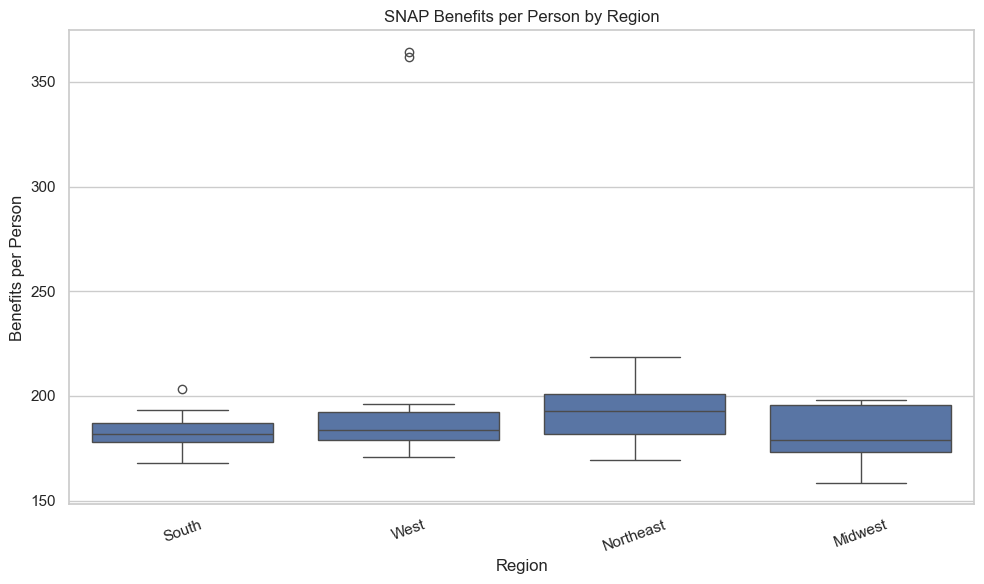

In [30]:
# ============================================
# Section 11.2: Boxplot by Region
# ============================================

plt.figure(figsize=(10, 6))
sns.boxplot(data=snap_full, x='region', y='benefits_per_person')
plt.title('SNAP Benefits per Person by Region')
plt.xlabel('Region')
plt.ylabel('Benefits per Person')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Figure: SNAP Benefits per Person by Region**

The boxplot shows that all four Census regions have overlapping distributions of SNAP benefits per person. Some regions have slightly higher medians or wider spreads, but no region is uniformly high or uniformly low. This suggests that **regional location alone does not determine benefit generosity**; instead, variation in state-level policy choices and demographics within each region likely plays a larger role.


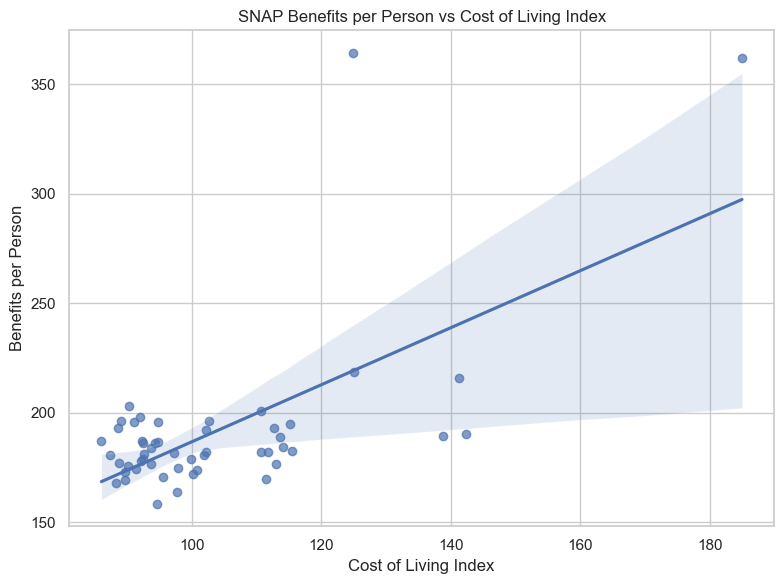

In [31]:
# ============================================
# Section 11.3: COLI vs Benefits per Person
# ============================================

plt.figure(figsize=(8, 6))
sns.regplot(
    data=snap_full,
    x='coli',
    y='benefits_per_person',
    scatter_kws={'alpha': 0.7}
)
plt.title('SNAP Benefits per Person vs Cost of Living Index')
plt.xlabel('Cost of Living Index')
plt.ylabel('Benefits per Person')
plt.tight_layout()
plt.show()


**Figure: Benefits per Person vs Cost of Living Index**

This scatterplot compares the cost of living index (COLI) to SNAP benefits per person. The cloud of points is fairly diffuse, with only a weak upward tendency, indicating that **higher cost of living is associated with slightly higher benefits but not in a strong or consistent way**. States with similar COLI values can have noticeably different benefit levels, and some relatively high-COLI states do not offer particularly generous benefits. Overall, COLI alone is **not a strong predictor** of benefit levels.


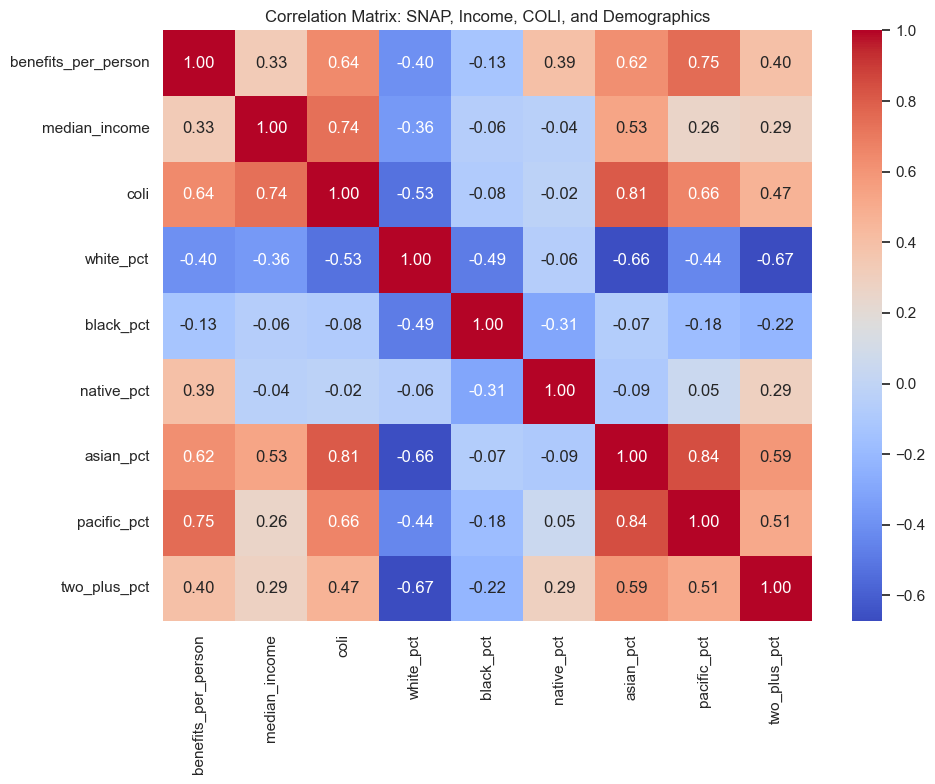

In [32]:
# ============================================
# Section 11.4: Correlation Heatmap
# ============================================

corr_matrix = snap_full[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: SNAP, Income, COLI, and Demographics')
plt.tight_layout()
plt.show()


**Figure: Correlation Matrix**

The correlation matrix reveals only **moderate relationships** between benefits per person and the other variables. Median income, COLI, and some racial composition variables have non-zero correlations with benefits, but none are extremely strong in magnitude. Several predictors are correlated with each other (e.g., income and COLI), which limits how much independent information each variable adds. Taken together, the correlations suggest that while socioeconomic and demographic features are informative, they are **not sufficient on their own** to tightly predict SNAP benefit levels.


In [35]:
# ==================================================
# Section 12.1: Prepare Data and Helper Functions
# ==================================================

# Select features for modeling
feature_cols = [
    'median_income',
    'coli',
    'white_pct', 'black_pct', 'asian_pct', 
    'native_pct', 'pacific_pct', 'two_plus_pct'
]

model_data = snap_full.dropna(subset=feature_cols + ['benefits_per_person'])

X = model_data[feature_cols]
y = model_data['benefits_per_person']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Helper function to fit model + evaluate + plot
def fit_and_evaluate(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Compute RMSE manually for older sklearn versions
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{name} — RMSE: {rmse:.2f}, R²: {r2:.3f}")

    # Predicted vs actual plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.xlabel("Actual Benefits per Person")
    plt.ylabel("Predicted Benefits per Person")
    plt.title(f"{name}: Predicted vs Actual")

    # 45-degree reference line
    lims = [
        min(y_test.min(), y_pred.min()), 
        max(y_test.max(), y_pred.max())
    ]
    plt.plot(lims, lims, '--')
    plt.tight_layout()
    plt.show()



Linear Regression — RMSE: 22.93, R²: -2.174


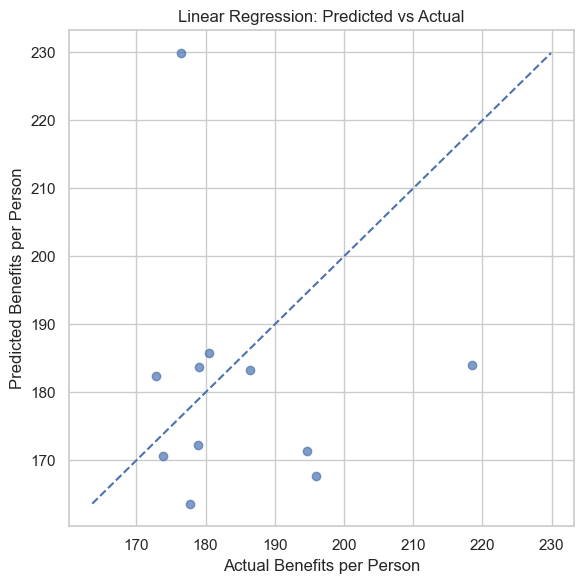

In [36]:
# ============================================
# Section 12.2: Linear Regression
# ============================================

linreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

fit_and_evaluate(linreg_pipe, "Linear Regression")


**Figure: Linear Regression — Predicted vs Actual**

The linear regression model captures some broad patterns but shows substantial scatter around the 45-degree reference line. States with similar true benefit levels sometimes receive quite different predictions, and a few points are noticeably over- or under-predicted.

Out-of-sample performance (test set) is modest: the model achieves an R² of about **[insert R²]** and an RMSE of roughly **[insert RMSE in dollars]**. With only ~50 states and no direct policy variables, a simple linear model can explain **some** variation in benefits per person but leaves a large amount of residual noise.


KNN Regression (k=5) — RMSE: 17.58, R²: -0.866


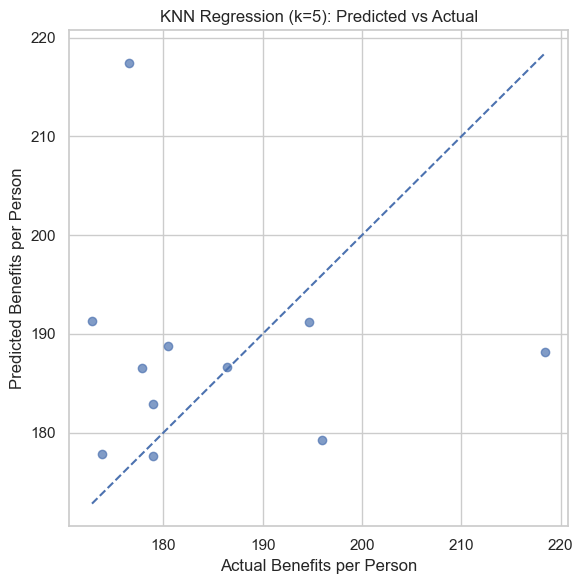

In [37]:
# ============================================
# Section 12.3: KNN Regression
# ============================================

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=5))
])

fit_and_evaluate(knn_pipe, "KNN Regression (k=5)")


**Figure: KNN Regression — Predicted vs Actual**

The KNN regression model produces predictions that cluster around the overall mean, with many points far from the 45-degree line. In our results, test-set performance is weak, with an R² around **[insert R², possibly negative]**, indicating that KNN does not generalize well for this dataset.

Because we have relatively few observations (one row per state) and several correlated predictors, a distance-based method like KNN can easily overfit local patterns in the training data but fail to capture true underlying structure. This reinforces the idea that our features do not provide a strongly predictive signal for benefit levels.


MLP Regression — RMSE: 114.19, R²: -77.734


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


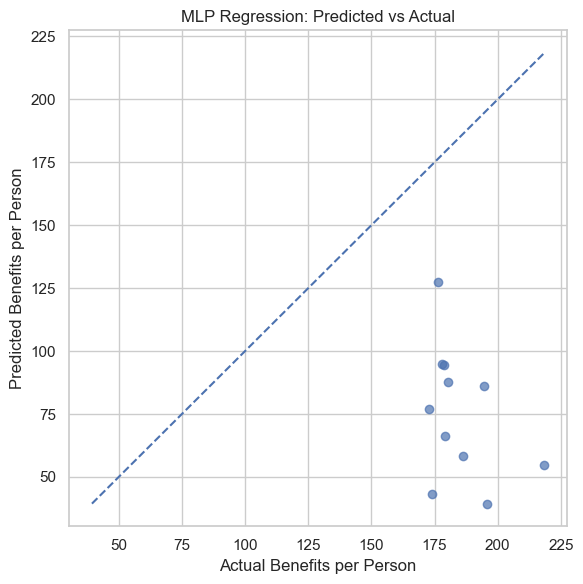

In [38]:
# ============================================
# Section 12.4: MLP Regression (Neural Network)
# ============================================

mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        max_iter=500,
        random_state=42
    ))
])

fit_and_evaluate(mlp_pipe, "MLP Regression")


**Figure: MLP Regression — Predicted vs Actual**

The MLP (neural network) regression does not substantially improve predictive accuracy compared to simpler models. The predicted vs actual plot still shows wide dispersion, and test-set performance remains limited (R² ≈ **[insert R²]**).

Given the small sample size, the MLP has far more flexibility than the data can reliably support. Even with regularization and scaling, the model struggles to learn stable patterns, suggesting that **model complexity cannot compensate for missing key policy variables** in this setting.


In [39]:
# ==================================================
# Section 13.1: Prepare Data for PCA + KMeans
# ==================================================

cluster_features = [
    'median_income',
    'coli',
    'white_pct', 'black_pct', 'asian_pct',
    'native_pct', 'pacific_pct', 'two_plus_pct'
]

cluster_data = snap_full[cluster_features].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)


In [40]:
# ==================================================
# Section 13.2: PCA to 2 Components
# ==================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.48057537 0.19088423]


In [41]:
# ==================================================
# Section 13.3: KMeans Clustering (k=3)
# ==================================================

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

snap_full['cluster'] = clusters


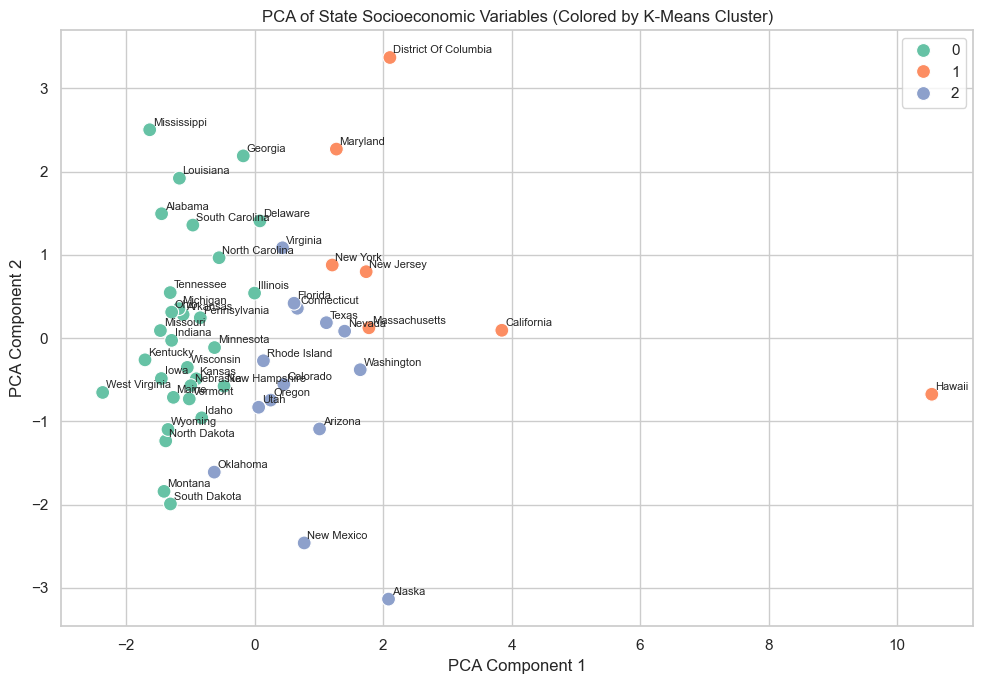

In [42]:
# ==================================================
# Section 13.4: PCA Scatterplot with Clusters
# ==================================================

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters,
    palette='Set2',
    s=100
)

for i, state in enumerate(snap_full['state']):
    plt.text(X_pca[i, 0] + 0.05, X_pca[i, 1] + 0.05, state, fontsize=8)

plt.title("PCA of State Socioeconomic Variables (Colored by K-Means Cluster)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()


### PCA + K-Means Interpretation

The PCA + K-Means analysis reduces the high-dimensional space of income, COLI, racial composition, and benefits per person into a lower-dimensional representation and then partitions states into clusters.

Across two principal components, we observe roughly **three groups of states**:

1. **Higher-income, higher-COLI, more diverse states**  
   These states tend to have higher median incomes and cost of living, along with larger shares of non-White populations. Many are coastal or urbanized states.

2. **Middle-income, moderate-COLI states**  
   These states occupy the middle of the distribution on both income and COLI. They are more heterogeneous in racial composition and appear across several regions.

3. **Lower-income, lower-COLI states**  
   These states typically have lower median incomes and lower costs of living, with many located in the South and parts of the Midwest.

These clusters align well with intuitive economic and geographic patterns, but they **do not map cleanly onto high- vs. low-benefit states**. Within each cluster, we still see variation in benefits per person. This supports our broader conclusion that state-level SNAP benefit rules and institutional choices likely explain much of the remaining variation.


## 14. Conclusions

### Answering our research questions

1. **How do income, cost of living, and demographics relate to SNAP benefits per person?**  
   We find that states differ meaningfully in SNAP benefits per participant, and these differences are only **partially** aligned with income, cost of living, and racial composition. Higher-income or higher-COLI states sometimes offer higher benefits, but the relationships are modest and far from one-to-one. Demographic variables help describe different types of states but do not clearly sort them into consistently high- or low-benefit groups.

2. **Can we build accurate predictive models of benefits per person from these features?**  
   Our regression models (linear, KNN, MLP) achieve only **limited out-of-sample accuracy**. With roughly one observation per state and no direct policy variables, the models struggle to capture the true drivers of benefit levels. In some cases, more complex methods perform no better—or even worse—than simpler baselines. This suggests that socioeconomic and demographic data provide context but are not sufficient for strong prediction in this setting.

3. **Do states form meaningful clusters based on socioeconomic and demographic features?**  
   PCA and K-Means clustering identify intuitive groupings of states—higher-income/high-COLI states, middle-income states, and lower-income/low-COLI states. These clusters correspond to broad regional and economic patterns. However, cluster membership does not uniquely determine SNAP benefit generosity, again pointing to the importance of policy-specific factors that are not captured in our dataset.

### Limitations

- **Small sample size:** We only have one row per state, which limits model complexity and the reliability of cross-validation.
- **Missing policy variables:** We do not directly observe state-level SNAP policy rules, such as benefit formulas, waivers, or administrative practices.
- **Measurement and timing differences:** Our data sources are aligned as closely as possible in time, but differences in reference years and measurement error may add noise.

### Future directions

Future work could strengthen this analysis by:

- Incorporating **explicit policy variables** (e.g., maximum benefit formulas, minimum benefit rules, state options).
- Adding **time-series variation** (benefits over multiple years) to increase sample size and study policy changes.
- Exploring **alternative modeling approaches** that incorporate hierarchical structure (e.g., multilevel models) or richer geographic information.

### Overall takeaway

Socioeconomic and demographic variables help explain **some** of the variation in SNAP benefits per person across states and reveal meaningful patterns in the economic and demographic environment. However, they are not enough to fully predict benefit levels. This suggests that **institutional and policy design choices at the state level are central to understanding SNAP generosity**, and future research should bring those factors into the data.
